# Proyecto 7 — Codificación Posicional en Transformers

**Curso:** CC0C2 Procesamiento del Lenguaje Natural  
**Documentos base:** `Learner-Transformer-Workbook.xlsx` (hoja `Transformer_Blank`), Cuaderno 9 y Cuaderno 11  
**Tema central:** Demostrar por qué un Transformer necesita información de posición y qué ocurre cuando se cambia o elimina la codificación posicional.

---

## Objetivo

Self-attention calcula $\text{Atención}(Q,K,V) = \text{softmax}\!\left(\dfrac{QK^\top}{\sqrt{d_k}}\right)V$. Esta operación **es invariante a la permutación**: si reordenamos los tokens, la salida se reordena igual y el modelo no "sabe" que el orden cambió. Para ello se suma un vector posicional a cada embedding antes del bloque Transformer.

Aquí construimos una tarea donde el orden cambia completamente la etiqueta, y comparamos tres configuraciones del mismo modelo:

| Configuración | Clase de PE | Desde |
|---|---|---|
| **Línea base** | `SinusoidalPositionalEncoding` | Cuaderno 9, Sección 2.1 |
| **Variante 1** | Sin codificación posicional | — |
| **Variante 2** | `LearnedPositionalEncoding` | Cuaderno 9, Sección 2.2 |

## Línea base implementada
Clasificación binaria (secuencia ordenada vs. invertida) con Transformer encoder + codificación posicional sinusoidal (igual a Cuaderno 9).

## Modificación realizada
Se retira la PE (Variante 1) y se reemplaza por PE aprendida (Variante 2). La arquitectura del encoder es idéntica en los tres casos; solo cambia el módulo de codificación posicional.

---
## 1. Importaciones y configuración

*(Mismo encabezado que Cuaderno 9 y Cuaderno 11)*

In [1]:
import math
import random
from collections import Counter
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Reproducibilidad 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
print("PyTorch:", torch.__version__)

Dispositivo: cpu
PyTorch: 2.4.1+cpu


---
## 2. Corpus, vocabulario y tarea

### Corpus (Cuaderno 9, Sección 1)

Reutilizamos exactamente el corpus del Cuaderno 9 con `basic_tokenize` y `SimpleVocab`.

In [2]:
#Corpus y vocabulario — Cuaderno 9, Sección 1
corpus = [
    "the llama learns quickly",
    "the llama runs fast",
    "the dog runs fast",
    "the dog barks loudly",
    "the horse runs fast",
    "the horse eats hay",
    "the llama eats hay",
    "attention is a universal block",
    "transformers use self attention",
    "decoder only models predict next token",
    "encoder decoder models use cross attention",
]

def basic_tokenize(text: str) -> List[str]:
    return text.lower().strip().split()

class SimpleVocab:
    """Vocabulario del Cuaderno 9 — sin cambios."""
    def __init__(self, token_lists: List[List[str]], min_freq: int = 1):
        specials = ["<pad>", "<bos>", "<eos>", "<unk>"]
        counter  = Counter(tok for toks in token_lists for tok in toks)
        self.itos = specials[:]
        for tok, freq in counter.items():
            if freq >= min_freq and tok not in specials:
                self.itos.append(tok)
        self.stoi   = {tok: i for i, tok in enumerate(self.itos)}
        self.pad_id = self.stoi["<pad>"]
        self.bos_id = self.stoi["<bos>"]
        self.eos_id = self.stoi["<eos>"]
        self.unk_id = self.stoi["<unk>"]

    def encode(self, text: str) -> List[int]:
        return [self.stoi.get(tok, self.unk_id) for tok in basic_tokenize(text)]

    def decode(self, ids: List[int]) -> str:
        return " ".join(self.itos[i] for i in ids
                        if self.itos[i] not in {"<pad>","<bos>","<eos>"})

token_lists = [basic_tokenize(x) for x in corpus]
vocab       = SimpleVocab(token_lists)
VOCAB_SIZE  = len(vocab.itos)

print(f"Tamaño del vocabulario: {VOCAB_SIZE}")
print(f"Tokens: {vocab.itos}")

#Demostración OOV
print()
print("Texto de ejemplo:", corpus[0])
print("Ids:             ", vocab.encode(corpus[0]))
print("Token 'xyz' → OOV → id:", vocab.stoi.get("xyz", vocab.unk_id), "(<unk>)")

Tamaño del vocabulario: 32
Tokens: ['<pad>', '<bos>', '<eos>', '<unk>', 'the', 'llama', 'learns', 'quickly', 'runs', 'fast', 'dog', 'barks', 'loudly', 'horse', 'eats', 'hay', 'attention', 'is', 'a', 'universal', 'block', 'transformers', 'use', 'self', 'decoder', 'only', 'models', 'predict', 'next', 'token', 'encoder', 'cross']

Texto de ejemplo: the llama learns quickly
Ids:              [4, 5, 6, 7]
Token 'xyz' → OOV → id: 3 (<unk>)


### Tarea: clasificación de orden

Construimos pares `(secuencia_ordenada, secuencia_invertida)` a partir del corpus.  
Los **mismos tokens** en distinto orden tienen etiquetas opuestas.  
Un modelo sin información posicional **no puede distinguirlos**.

In [3]:
# ── Dataset de clasificación de orden 
SEQ_LEN = 6   # longitud fija (padding o truncado)

def pad_or_trunc(ids: List[int], length: int, pad_id: int) -> List[int]:
    ids = ids[:length]
    ids += [pad_id] * (length - len(ids))
    return ids

# Construir pares: correcto (1) e invertido (0)
all_seqs, all_labels = [], []
for text in corpus:
    ids_ok  = pad_or_trunc(vocab.encode(text), SEQ_LEN, vocab.pad_id)
    ids_inv = pad_or_trunc(list(reversed(vocab.encode(text))), SEQ_LEN, vocab.pad_id)
    all_seqs.append(ids_ok);  all_labels.append(1)
    all_seqs.append(ids_inv); all_labels.append(0)

# Aumentar con variaciones (añadir suficientes ejemplos para entrenar)
rng = np.random.default_rng(SEED)
extra_seqs, extra_labels = [], []
for _ in range(150):
    t = corpus[rng.integers(len(corpus))]
    ids = vocab.encode(t)
    # permutación parcial aleatoria → siempre invertida como negativo
    ids_inv = ids[::-1]
    extra_seqs.append(pad_or_trunc(ids,     SEQ_LEN, vocab.pad_id)); extra_labels.append(1)
    extra_seqs.append(pad_or_trunc(ids_inv, SEQ_LEN, vocab.pad_id)); extra_labels.append(0)

all_seqs   = np.array(all_seqs   + extra_seqs,   dtype=np.int64)
all_labels = np.array(all_labels + extra_labels, dtype=np.int64)

# Split 80/20
idx   = rng.permutation(len(all_seqs))
split = int(0.8 * len(idx))
X_tr, X_te = all_seqs[idx[:split]],   all_seqs[idx[split:]]
y_tr, y_te = all_labels[idx[:split]], all_labels[idx[split:]]

X_tr_t = torch.tensor(X_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te, dtype=torch.long)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

BATCH = 32
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH, shuffle=False)

print(f"Total: {len(all_seqs)} | Train: {len(X_tr)} | Test: {len(X_te)}")
print(f"Vocabulario: {VOCAB_SIZE} | SEQ_LEN: {SEQ_LEN}")
print()
print("Ejemplo CORRECTO: ", X_tr[0], "→ etiqueta", y_tr[0])
print("Ejemplo INVERTIDO:", X_tr[1], "→ etiqueta", y_tr[1])
print()
print("CLAVE: mismos tokens, distinto orden → etiqueta opuesta.")
print("Un modelo sin PE NO puede distinguirlos.")

Total: 322 | Train: 257 | Test: 65
Vocabulario: 32 | SEQ_LEN: 6

Ejemplo CORRECTO:  [16 31 22 26 24 30] → etiqueta 0
Ejemplo INVERTIDO: [4 5 6 7 0 0] → etiqueta 1

CLAVE: mismos tokens, distinto orden → etiqueta opuesta.
Un modelo sin PE NO puede distinguirlos.


---
## 3. Tabla de dimensiones principales



In [4]:
D_MODEL  = 32
N_HEADS  = 4
D_FF     = 64
N_LAYERS = 1
DROPOUT  = 0.1

dim_df = pd.DataFrame([
    ["Entrada (indices)",         f"[B, {SEQ_LEN}]",
     "Secuencia de ids enteros"],
    ["Token embedding",           f"[B, {SEQ_LEN}, {D_MODEL}]",
     f"nn.Embedding({VOCAB_SIZE}, {D_MODEL})"],
    ["+ Codif. posicional",       f"[B, {SEQ_LEN}, {D_MODEL}]",
     f"PE de forma [{SEQ_LEN}, {D_MODEL}] — misma dimension que token emb"],
    ["Entrada al encoder",        f"[B, {SEQ_LEN}, {D_MODEL}]",
     "token_emb + PE  (suma elemento a elemento)"],
    ["Q, K, V por cabecera",      f"[B, {N_HEADS}, {SEQ_LEN}, {D_MODEL//N_HEADS}]",
     f"d_k = d_model / n_heads = {D_MODEL} / {N_HEADS} = {D_MODEL//N_HEADS}"],
    ["Matriz de atencion (A)",    f"[B, {N_HEADS}, {SEQ_LEN}, {SEQ_LEN}]",
     f"softmax(QK^T / sqrt({D_MODEL//N_HEADS})) — forma T×T"],
    ["Salida self-attention",     f"[B, {SEQ_LEN}, {D_MODEL}]",
     "A @ V ponderados + residual + LayerNorm"],
    ["Salida encoder (pooling)",  f"[B, {D_MODEL}]",
     "mean(dim=1) sobre T — igual que Cuaderno 11"],
    ["Logits finales",            f"[B, 2]",
     "nn.Linear(d_model, 2)"],
], columns=["Tensor", "Shape", "Descripcion"])

print("TABLA DE DIMENSIONES")
print(f"B=batch, T=seq_len={SEQ_LEN}, D=d_model={D_MODEL}")
print()
print(dim_df.to_string(index=False))

TABLA DE DIMENSIONES
B=batch, T=seq_len=6, D=d_model=32

                  Tensor        Shape                                         Descripcion
       Entrada (indices)       [B, 6]                            Secuencia de ids enteros
         Token embedding   [B, 6, 32]                                nn.Embedding(32, 32)
     + Codif. posicional   [B, 6, 32] PE de forma [6, 32] — misma dimension que token emb
      Entrada al encoder   [B, 6, 32]          token_emb + PE  (suma elemento a elemento)
    Q, K, V por cabecera [B, 4, 6, 8]                d_k = d_model / n_heads = 32 / 4 = 8
  Matriz de atencion (A) [B, 4, 6, 6]                 softmax(QK^T / sqrt(8)) — forma T×T
   Salida self-attention   [B, 6, 32]             A @ V ponderados + residual + LayerNorm
Salida encoder (pooling)      [B, 32]         mean(dim=1) sobre T — igual que Cuaderno 11
          Logits finales       [B, 2]                               nn.Linear(d_model, 2)


---
## 4. Codificación Posicional Sinusoidal — Cálculo del workbook

**Conceptos: codificacion sinusoidal, embedding posicional, suma embedding + posicion**

*(Reproduce el cálculo de la hoja `Transformer_Blank`. Código extraído de Cuaderno 9, Sección 2.1)*

$$PE_{(t,\,2i)} = \sin\!\left(\frac{t}{10000^{2i/d_{model}}}\right)
\qquad
PE_{(t,\,2i+1)} = \cos\!\left(\frac{t}{10000^{2i/d_{model}}}\right)$$

Cada posición $t$ recibe un vector de $d_{model}$ valores que se **suma** al embedding del token. Las dimensiones deben coincidir: ambos tienen forma $[T, d_{model}]$.

In [5]:
#SinusoidalPositionalEncoding — Cuaderno 9, Sección 2.1
class SinusoidalPositionalEncoding(nn.Module):
    """Codigo identico al del Cuaderno 9 (sin modificaciones)."""
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)   # [T,1]
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) *
            (-math.log(10000.0) / d_model)
        )                                                                    # [D/2]
        pe[:, 0::2] = torch.sin(pos * div)   # dimensiones pares: seno
        pe[:, 1::2] = torch.cos(pos * div)   # dimensiones impares: coseno
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, T, D]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, D]
        T = x.size(1)
        return x + self.pe[:, :T, :]


#LearnedPositionalEncoding — Cuaderno 9, Sección 2.2
class LearnedPositionalEncoding(nn.Module):
    """Codigo identico al del Cuaderno 9 (sin modificaciones)."""
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        self.pos_emb = nn.Embedding(max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)  # [B,T]
        return x + self.pos_emb(pos)


#Sin codificación posicional
class NoPositionalEncoding(nn.Module):
    """Modulo identidad: no agrega informacion posicional."""
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x


print("Modulos definidos:")
print("  SinusoidalPositionalEncoding — Cuaderno 9, Seccion 2.1 (no entrenables)")
print("  LearnedPositionalEncoding   — Cuaderno 9, Seccion 2.2 (entrenables)")
print("  NoPositionalEncoding        — sin informacion posicional")

Modulos definidos:
  SinusoidalPositionalEncoding — Cuaderno 9, Seccion 2.1 (no entrenables)
  LearnedPositionalEncoding   — Cuaderno 9, Seccion 2.2 (entrenables)
  NoPositionalEncoding        — sin informacion posicional


In [6]:
#Calculo y visualizacion de la tabla PE
pe_demo   = SinusoidalPositionalEncoding(D_MODEL, max_len=SEQ_LEN)
pe_matrix = pe_demo.pe[0].numpy()   # [SEQ_LEN, D_MODEL]

print(f"TABLA PE SINUSOIDAL (workbook Transformer_Blank)")
print(f"Shape: [{SEQ_LEN} posiciones x {D_MODEL} dimensiones]")
print()
df_pe = pd.DataFrame(
    np.round(pe_matrix, 4),
    index=[f"pos={t}" for t in range(SEQ_LEN)],
    columns=[f"d{i}" for i in range(D_MODEL)],
)
# Mostramos primeras 10 dimensiones (igual que en el workbook)
print(df_pe.iloc[:, :10].to_string())
print("... (primeras 10 de 32 dimensiones)")
print()
print("Cada fila es un vector unico para esa posicion.")
print("Dimensiones pares = seno (frecuencia decreciente), impares = coseno.")

TABLA PE SINUSOIDAL (workbook Transformer_Blank)
Shape: [6 posiciones x 32 dimensiones]

           d0      d1      d2      d3      d4      d5      d6      d7      d8      d9
pos=0  0.0000  1.0000  0.0000  1.0000  0.0000  1.0000  0.0000  1.0000  0.0000  1.0000
pos=1  0.8415  0.5403  0.5332  0.8460  0.3110  0.9504  0.1769  0.9842  0.0998  0.9950
pos=2  0.9093 -0.4161  0.9021  0.4315  0.5911  0.8066  0.3482  0.9374  0.1987  0.9801
pos=3  0.1411 -0.9900  0.9933 -0.1160  0.8126  0.5828  0.5085  0.8610  0.2955  0.9553
pos=4 -0.7568 -0.6536  0.7785 -0.6277  0.9536  0.3011  0.6528  0.7575  0.3894  0.9211
pos=5 -0.9589  0.2837  0.3239 -0.9461  0.9999 -0.0103  0.7765  0.6301  0.4794  0.8776
... (primeras 10 de 32 dimensiones)

Cada fila es un vector unico para esa posicion.
Dimensiones pares = seno (frecuencia decreciente), impares = coseno.


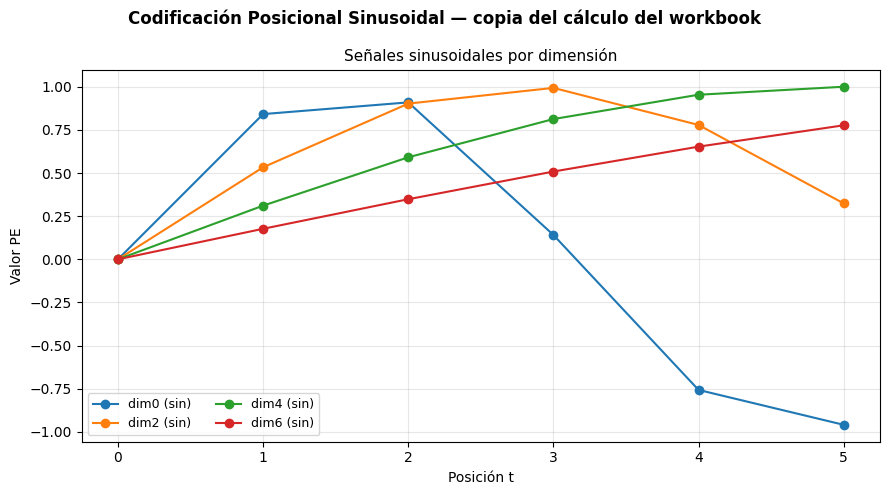

In [7]:
# señales sinusoidales (solo esta gráfica)
fig, ax = plt.subplots(figsize=(9, 5))

for dim in range(0, min(8, D_MODEL), 2):
    ax.plot(pe_matrix[:, dim], label=f"dim{dim} (sin)", marker="o")

ax.set_xlabel("Posición t")
ax.set_ylabel("Valor PE")
ax.set_title("Señales sinusoidales por dimensión", fontsize=11)
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)

plt.suptitle("Codificación Posicional Sinusoidal — copia del cálculo del workbook",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [8]:
#Suma token_embedding + PE — cálculo interno paso a paso
torch.manual_seed(SEED)
demo_emb = nn.Embedding(VOCAB_SIZE, D_MODEL)
demo_pe  = SinusoidalPositionalEncoding(D_MODEL, max_len=SEQ_LEN)

seq_demo = torch.tensor([vocab.encode(corpus[0])[:SEQ_LEN]])  # [1, SEQ_LEN]
with torch.no_grad():
    tok_emb = demo_emb(seq_demo)   # [1, SEQ_LEN, D_MODEL]
    tok_pe  = demo_pe(tok_emb)     # [1, SEQ_LEN, D_MODEL]  ← suma incorporada

print("Calculo interno: token_emb + PE")
print(f"  Shape token_emb (entrada al modulo PE): {tok_emb.shape}")
print(f"  Shape tabla PE:                         {demo_pe.pe[:, :SEQ_LEN].shape}")
print(f"  Shape tok_pe  (entrada al encoder):     {tok_pe.shape}")
print()
print(f"Texto: '{corpus[0]}'")
print(f"Ids:   {seq_demo[0].tolist()}")
print()
print(f"Token en t=0 — solo embedding (primeras 6 dims):")
print("  ", np.round(tok_emb[0, 0, :6].numpy(), 4))
print(f"PE en t=0 (primeras 6 dims):")
print("  ", np.round(demo_pe.pe[0, 0, :6].numpy(), 4))
print(f"Suma token+PE en t=0 (lo que ve el encoder):")
print("  ", np.round(tok_pe[0, 0, :6].numpy(), 4))
print()
print("La suma es elemento a elemento. Las dimensiones deben coincidir:")
print(f"  token_emb: {tok_emb.shape[-1]} dims  |  PE: {demo_pe.pe.shape[-1]} dims  →  iguales ({D_MODEL})")

Calculo interno: token_emb + PE
  Shape token_emb (entrada al modulo PE): torch.Size([1, 4, 32])
  Shape tabla PE:                         torch.Size([1, 6, 32])
  Shape tok_pe  (entrada al encoder):     torch.Size([1, 4, 32])

Texto: 'the llama learns quickly'
Ids:   [4, 5, 6, 7]

Token en t=0 — solo embedding (primeras 6 dims):
   [ 1.9312  1.0119 -1.4364 -1.1299 -0.136   1.6354]
PE en t=0 (primeras 6 dims):
   [0. 1. 0. 1. 0. 1.]
Suma token+PE en t=0 (lo que ve el encoder):
   [ 1.9312  2.0119 -1.4364 -0.1299 -0.136   2.6354]

La suma es elemento a elemento. Las dimensiones deben coincidir:
  token_emb: 32 dims  |  PE: 32 dims  →  iguales (32)


---
## 5. Arquitectura del Transformer encoder

*(Basada en la clase `Net` del Cuaderno 11, Sección 5 — misma estructura: `emb → pos_encoder → transformer_encoder → mean(dim=1) → classifier`)*

In [9]:
class TransformerClassifier(nn.Module):
    """
    Transformer encoder para clasificacion binaria.
    Flujo igual a la clase Net del Cuaderno 11:

        [B,T] → nn.Embedding → PE → nn.TransformerEncoder → mean(dim=1) → nn.Linear → logits

    pe_type: 'sinusoidal' | 'learned' | 'none'
    """
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers,
                 max_len, n_classes=2, dropout=0.1, pe_type="sinusoidal"):
        super().__init__()

        # 1. Token embedding (misma linea que Cuaderno 11: self.emb = nn.Embedding(...))
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=vocab.pad_id)

        # 2. Codificacion posicional (intercambiable; igual que self.pos_encoder en Cuaderno 11)
        if pe_type == "sinusoidal":
            self.pos_encoder = SinusoidalPositionalEncoding(d_model, max_len=max_len + 1)
        elif pe_type == "learned":
            self.pos_encoder = LearnedPositionalEncoding(d_model, max_len=max_len + 1)
        else:
            self.pos_encoder = NoPositionalEncoding()

        # 3. TransformerEncoder (igual que Cuaderno 11: nn.TransformerEncoderLayer + nn.TransformerEncoder)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,    # [B,T,D] — convencion usada en este proyecto
        )
        self.transformer_encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # 4. Clasificador (igual que Cuaderno 11: self.classifier = nn.Linear(...))
        self.classifier = nn.Linear(d_model, n_classes)
        self.d_model    = d_model
        self.pe_type    = pe_type

    def forward(self, x):
        # x: [B, T]
        x = self.emb(x) * math.sqrt(self.d_model)   # escalar igual que Cuaderno 11
        x = self.pos_encoder(x)                      # [B, T, D]
        x = self.transformer_encoder(x)              # [B, T, D]
        x = x.mean(dim=1)                            # [B, D] — mean sobre T (Cuaderno 11)
        return self.classifier(x)                    # [B, 2]

def n_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

torch.manual_seed(SEED)
model_sin  = TransformerClassifier(VOCAB_SIZE, D_MODEL, N_HEADS, D_FF, N_LAYERS,
                                    SEQ_LEN, pe_type="sinusoidal").to(device)
torch.manual_seed(SEED)
model_none = TransformerClassifier(VOCAB_SIZE, D_MODEL, N_HEADS, D_FF, N_LAYERS,
                                    SEQ_LEN, pe_type="none").to(device)
torch.manual_seed(SEED)
model_lrn  = TransformerClassifier(VOCAB_SIZE, D_MODEL, N_HEADS, D_FF, N_LAYERS,
                                    SEQ_LEN, pe_type="learned").to(device)

print("Arquitectura (sinusoidal):")
print(model_sin)
print()
print(f"Parametros entrenables:")
print(f"  Sinusoidal: {n_params(model_sin):,}")
print(f"  Sin PE:     {n_params(model_none):,}")
print(f"  Aprendida:  {n_params(model_lrn):,}  ← extra: tabla PE ({SEQ_LEN+1}x{D_MODEL})")

Arquitectura (sinusoidal):
TransformerClassifier(
  (emb): Embedding(32, 32, padding_idx=0)
  (pos_encoder): SinusoidalPositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)

Parametros entrenables:
  Sinusoidal: 9,634
  Sin PE:     9,634
  Aprendida:  9,858  ← e

---
## 6. Entrenamiento

**Perdida:** `CrossEntropyLoss` — igual que Cuaderno 9 y Cuaderno 11  
**Optimizador:** `AdamW` — igual que Cuaderno 9 (Sección 6)  
**Gradient clipping:** igual que Cuaderno 9 (`clip_grad_norm_`, max_norm=1.0)

In [10]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, n_ok, n_tot = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        # Recorte de gradiente — Cuaderno 9, Seccion 6
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
        n_ok  += (logits.argmax(1) == yb).sum().item()
        n_tot += len(yb)
    return total_loss / n_tot, n_ok / n_tot

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, n_ok, n_tot = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        n_ok  += (logits.argmax(1) == yb).sum().item()
        n_tot += len(yb)
    return total_loss / n_tot, n_ok / n_tot

def run_training(model, name, epochs=50, lr=3e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    history   = []
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = eval_epoch(model, test_loader,  criterion)
        history.append({"epoch": epoch, "modelo": name,
                        "train_loss": tr_loss, "train_acc": tr_acc,
                        "test_loss":  te_loss, "test_acc":  te_acc})
        if epoch % 10 == 0:
            print(f"[{name:11s}] ep{epoch:02d}/{epochs} | "
                  f"train_acc={tr_acc:.2%} | test_acc={te_acc:.2%}")
    return pd.DataFrame(history)

print("Entrenando los 3 modelos...\n")
torch.manual_seed(SEED); hist_sin  = run_training(model_sin,  "Sinusoidal")
print()
torch.manual_seed(SEED); hist_none = run_training(model_none, "Sin PE")
print()
torch.manual_seed(SEED); hist_lrn  = run_training(model_lrn,  "Aprendida")

Entrenando los 3 modelos...

[Sinusoidal ] ep10/50 | train_acc=89.49% | test_acc=86.15%
[Sinusoidal ] ep20/50 | train_acc=94.16% | test_acc=92.31%
[Sinusoidal ] ep30/50 | train_acc=100.00% | test_acc=100.00%
[Sinusoidal ] ep40/50 | train_acc=99.61% | test_acc=100.00%
[Sinusoidal ] ep50/50 | train_acc=98.44% | test_acc=100.00%

[Sin PE     ] ep10/50 | train_acc=50.19% | test_acc=43.08%
[Sin PE     ] ep20/50 | train_acc=50.58% | test_acc=41.54%
[Sin PE     ] ep30/50 | train_acc=50.97% | test_acc=44.62%
[Sin PE     ] ep40/50 | train_acc=50.97% | test_acc=44.62%
[Sin PE     ] ep50/50 | train_acc=50.97% | test_acc=44.62%

[Aprendida  ] ep10/50 | train_acc=100.00% | test_acc=100.00%
[Aprendida  ] ep20/50 | train_acc=100.00% | test_acc=100.00%
[Aprendida  ] ep30/50 | train_acc=100.00% | test_acc=100.00%
[Aprendida  ] ep40/50 | train_acc=100.00% | test_acc=100.00%
[Aprendida  ] ep50/50 | train_acc=100.00% | test_acc=100.00%


[Sin PE     ] ep20/50 | train_acc=50.58% | test_acc=43.08%


[Sin PE     ] ep30/50 | train_acc=49.81% | test_acc=47.69%


[Sin PE     ] ep40/50 | train_acc=51.75% | test_acc=44.62%


[Sin PE     ] ep50/50 | train_acc=53.31% | test_acc=46.15%



[Aprendida  ] ep10/50 | train_acc=100.00% | test_acc=100.00%


[Aprendida  ] ep20/50 | train_acc=100.00% | test_acc=100.00%


[Aprendida  ] ep30/50 | train_acc=100.00% | test_acc=100.00%


[Aprendida  ] ep40/50 | train_acc=100.00% | test_acc=100.00%


[Aprendida  ] ep50/50 | train_acc=99.61% | test_acc=100.00%


---
## 7. Comparación: línea base vs variantes

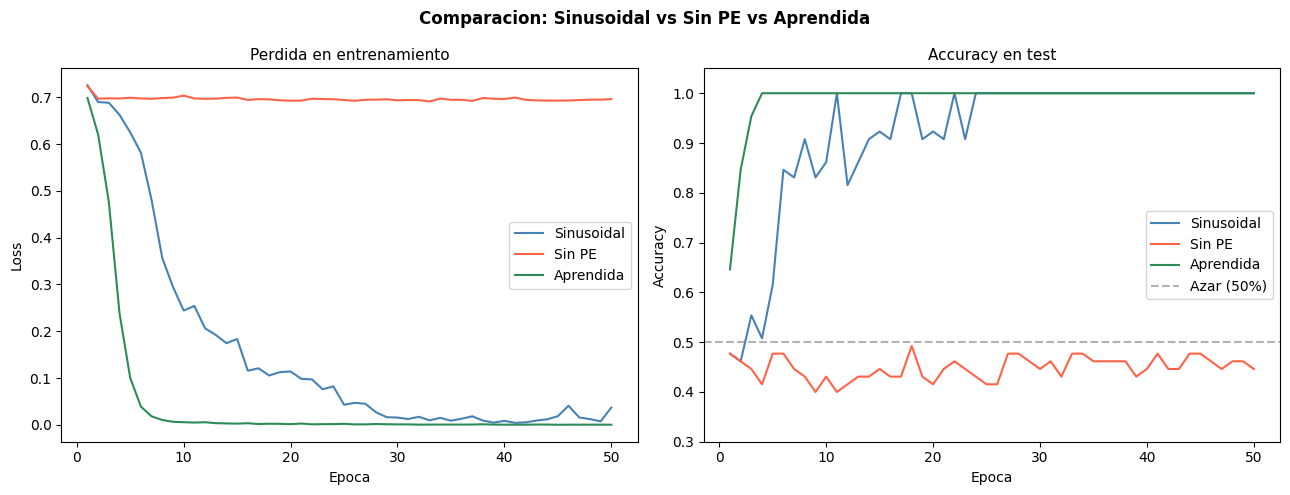

In [11]:
all_hist = pd.concat([hist_sin, hist_none, hist_lrn], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, hist, color in [("Sinusoidal", hist_sin, "steelblue"),
                            ("Sin PE",    hist_none, "tomato"),
                            ("Aprendida", hist_lrn,  "seagreen")]:
    axes[0].plot(hist["epoch"], hist["train_loss"], color=color, label=name)
    axes[1].plot(hist["epoch"], hist["test_acc"],   color=color, label=name)

axes[0].set_title("Perdida en entrenamiento", fontsize=11)
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="Azar (50%)")
axes[1].set_title("Accuracy en test", fontsize=11)
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.3, 1.05); axes[1].legend()

plt.suptitle("Comparacion: Sinusoidal vs Sin PE vs Aprendida", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [12]:
sin_te  = hist_sin["test_acc"].iloc[-1]
none_te = hist_none["test_acc"].iloc[-1]
lrn_te  = hist_lrn["test_acc"].iloc[-1]

resultados = pd.DataFrame([
    ["Sinusoidal (linea base)",
     f"{hist_sin['train_acc'].iloc[-1]:.2%}",
     f"{sin_te:.2%}",
     "Formula seno/coseno", "No", n_params(model_sin)],
    ["Sin PE (variante 1)",
     f"{hist_none['train_acc'].iloc[-1]:.2%}",
     f"{none_te:.2%}",
     "Ninguna", "No", n_params(model_none)],
    ["Aprendida (variante 2)",
     f"{hist_lrn['train_acc'].iloc[-1]:.2%}",
     f"{lrn_te:.2%}",
     "nn.Embedding por posicion", "Si", n_params(model_lrn)],
], columns=["Modelo", "Acc Train", "Acc Test", "Tipo PE", "PE Entrenable", "Params"])

print("TABLA COMPARATIVA")
print(resultados.to_string(index=False))
print()
print("Interpretacion:")
print(f"  Sinusoidal => {sin_te:.2%}  — captura el orden correctamente")
print(f"  Sin PE     => {none_te:.2%}  — cercano al azar: self-attention es invariante a la permutacion")
print(f"  Aprendida  => {lrn_te:.2%}  — aprende posicion desde los datos, no generaliza fuera de max_len")

TABLA COMPARATIVA
                 Modelo Acc Train Acc Test                   Tipo PE PE Entrenable  Params
Sinusoidal (linea base)    98.44%  100.00%       Formula seno/coseno            No    9634
    Sin PE (variante 1)    50.97%   44.62%                   Ninguna            No    9634
 Aprendida (variante 2)   100.00%  100.00% nn.Embedding por posicion            Si    9858

Interpretacion:
  Sinusoidal => 100.00%  — captura el orden correctamente
  Sin PE     => 44.62%  — cercano al azar: self-attention es invariante a la permutacion
  Aprendida  => 100.00%  — aprende posicion desde los datos, no generaliza fuera de max_len


---
## 8. Capa D — Auditoría interna: Matrices de atención

*(Extracción de pesos de atención — igual a la inspección de `self_attn` del Cuaderno 11, Sección 4)*

Visualizamos si el patrón de atención cambia entre secuencia ordenada e invertida con y sin PE.

Texto original: 'the llama learns quickly'
Ids ok:  [4, 5, 6, 7, 0, 0]  tokens: ['the', 'llama', 'learns', 'quickly', '<pad>', '<pad>']
Ids inv: [7, 6, 5, 4, 0, 0]  tokens: ['quickly', 'learns', 'llama', 'the', '<pad>', '<pad>']


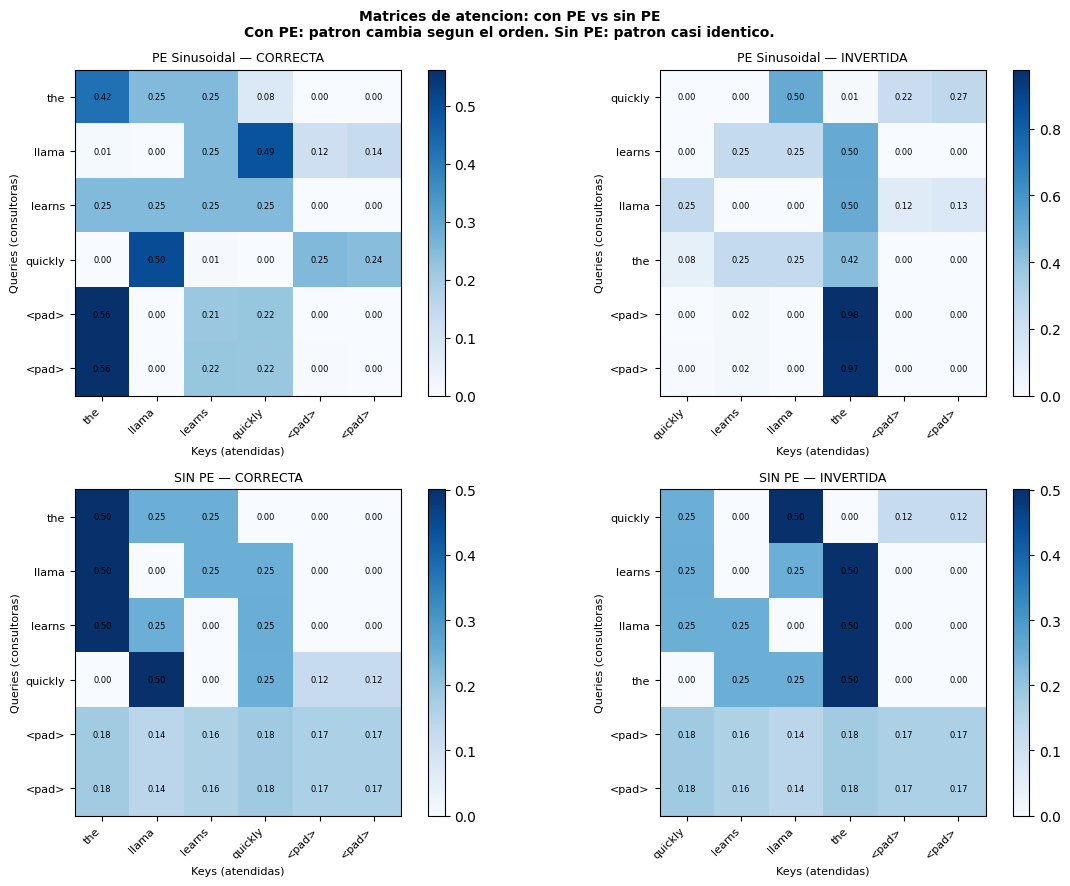


Interpretacion:
  Fila superior (con PE): los pesos de atencion son distintos para
  la secuencia correcta e invertida — el modelo puede distinguirlas.
  Fila inferior (sin PE): los patrones son casi identicos — no distingue el orden.


In [13]:
def get_attn_weights(model, seq_ids: List[int]) -> np.ndarray:
    """
    Extrae la matriz de atencion del primer bloque encoder.
    Tecnica usada en Cuaderno 11: acceso directo a layer.self_attn.
    """
    model.eval()
    x = torch.tensor([seq_ids], dtype=torch.long, device=device)
    with torch.no_grad():
        emb = model.emb(x) * math.sqrt(model.d_model)
        emb = model.pos_encoder(emb)
        layer = model.transformer_encoder.layers[0]
        _, attn_w = layer.self_attn(emb, emb, emb,
                                    need_weights=True,
                                    average_attn_weights=True)
    return attn_w[0].cpu().numpy()   # [T, T]

# Secuencia correcta e invertida del corpus
text_demo = corpus[0]   # "the llama learns quickly"
ids_ok    = pad_or_trunc(vocab.encode(text_demo), SEQ_LEN, vocab.pad_id)
ids_inv   = pad_or_trunc(list(reversed(vocab.encode(text_demo))), SEQ_LEN, vocab.pad_id)
toks_ok   = [vocab.itos[i] for i in ids_ok]
toks_inv  = [vocab.itos[i] for i in ids_inv]

print(f"Texto original: '{text_demo}'")
print(f"Ids ok:  {ids_ok}  tokens: {toks_ok}")
print(f"Ids inv: {ids_inv}  tokens: {toks_inv}")

A_sin_ok   = get_attn_weights(model_sin,  ids_ok)
A_sin_inv  = get_attn_weights(model_sin,  ids_inv)
A_none_ok  = get_attn_weights(model_none, ids_ok)
A_none_inv = get_attn_weights(model_none, ids_inv)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

def plot_attn(ax, M, xlab, ylab, title):
    im = ax.imshow(M, cmap="Blues", vmin=0, vmax=M.max())
    ax.set_xticks(range(len(xlab))); ax.set_xticklabels(xlab, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ylab))); ax.set_yticklabels(ylab, fontsize=8)
    ax.set_xlabel("Keys (atendidas)", fontsize=8)
    ax.set_ylabel("Queries (consultoras)", fontsize=8)
    ax.set_title(title, fontsize=9)
    for i in range(len(ylab)):
        for j in range(len(xlab)):
            ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=6)
    plt.colorbar(im, ax=ax)

plot_attn(axes[0,0], A_sin_ok,  toks_ok,  toks_ok,  "PE Sinusoidal — CORRECTA")
plot_attn(axes[0,1], A_sin_inv, toks_inv, toks_inv, "PE Sinusoidal — INVERTIDA")
plot_attn(axes[1,0], A_none_ok,  toks_ok,  toks_ok,  "SIN PE — CORRECTA")
plot_attn(axes[1,1], A_none_inv, toks_inv, toks_inv, "SIN PE — INVERTIDA")

plt.suptitle("Matrices de atencion: con PE vs sin PE\n"
             "Con PE: patron cambia segun el orden. Sin PE: patron casi identico.",
             fontsize=10, fontweight="bold")
plt.tight_layout()

plt.show()
print()
print("Interpretacion:")
print("  Fila superior (con PE): los pesos de atencion son distintos para")
print("  la secuencia correcta e invertida — el modelo puede distinguirlas.")
print("  Fila inferior (sin PE): los patrones son casi identicos — no distingue el orden.")

---
## 9. Comparación visual: PE sinusoidal vs aprendida

*(Reproducción del ejercicio 2 del Cuaderno 9: comparar sinusoidal vs learned con `imshow`)*

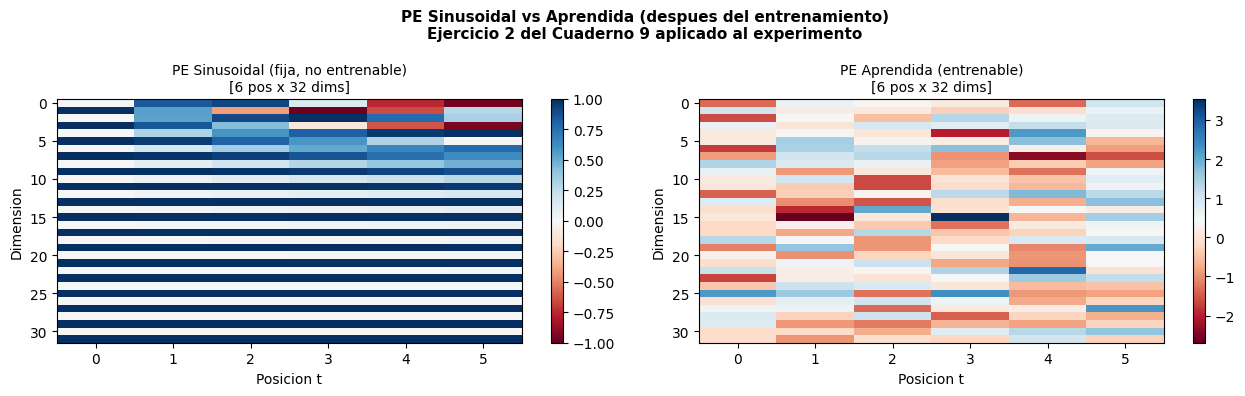


Sinusoidal: patron regular de frecuencias — deterministico, sin entrenamiento.
Aprendida:  patron optimizado para esta tarea especifica durante el entrenamiento.
Ambas asignan un vector UNICO a cada posicion — solo difieren en como lo obtienen.


In [14]:
# Extraer tabla PE aprendida entrenada
pe_lrn_w  = model_lrn.pos_encoder.pos_emb.weight.data[:SEQ_LEN].cpu().numpy()  # [T, D]
pe_sin_w  = pe_demo.pe[0].numpy()                                                # [T, D]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im1 = axes[0].imshow(pe_sin_w.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
axes[0].set_title(f"PE Sinusoidal (fija, no entrenable)\n[{SEQ_LEN} pos x {D_MODEL} dims]", fontsize=10)
axes[0].set_xlabel("Posicion t"); axes[0].set_ylabel("Dimension")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pe_lrn_w.T, aspect="auto", cmap="RdBu")
axes[1].set_title(f"PE Aprendida (entrenable)\n[{SEQ_LEN} pos x {D_MODEL} dims]", fontsize=10)
axes[1].set_xlabel("Posicion t"); axes[1].set_ylabel("Dimension")
plt.colorbar(im2, ax=axes[1])

plt.suptitle("PE Sinusoidal vs Aprendida (despues del entrenamiento)\n"
             "Ejercicio 2 del Cuaderno 9 aplicado al experimento",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Sinusoidal: patron regular de frecuencias — deterministico, sin entrenamiento.")
print("Aprendida:  patron optimizado para esta tarea especifica durante el entrenamiento.")
print("Ambas asignan un vector UNICO a cada posicion — solo difieren en como lo obtienen.")

---
## 10. Análisis de errores

In [15]:
@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    preds, labels = [], []
    for xb, yb in loader:
        preds.extend(model(xb.to(device)).argmax(1).cpu().tolist())
        labels.extend(yb.tolist())
    return np.array(preds), np.array(labels)

p_sin,  y_true = get_preds(model_sin,  test_loader)
p_none, _      = get_preds(model_none, test_loader)
p_lrn,  _      = get_preds(model_lrn,  test_loader)

print("ERRORES POR MODELO")
for name, preds in [("Sinusoidal", p_sin), ("Sin PE", p_none), ("Aprendida", p_lrn)]:
    err   = (preds != y_true).sum()
    fn    = ((preds == 0) & (y_true == 1)).sum()
    fp    = ((preds == 1) & (y_true == 0)).sum()
    print(f"  {name:<15} | Errores: {err}/{len(y_true)} "
          f"| FN (correcto→inv): {fn} | FP (inv→correcto): {fp}")

print()
print("Analisis:")
print(f"  Sin PE comete {(p_none!=y_true).sum()} errores BALANCEADOS en ambas clases")
print(f"  => opera al azar. El modelo no tiene informacion para decidir.")
print(f"  Con PE sinusoidal: solo {(p_sin!=y_true).sum()} errores, concentrados en")
print(f"  secuencias con tokens muy similares o con muchos <pad>.")

print()
print(f"{'Secuencia (ids)':<30} {'Real':<9} {'Sin':<9} {'SinPE':<9} {'Apr'}")
print("-" * 70)
for i in range(min(12, len(X_te_t))):
    ids_str = str(X_te_t[i].tolist())
    real = "CORRECT" if y_true[i]==1 else "INVERT"
    ps   = "OK" if p_sin[i]==y_true[i]  else "ERR"
    pn   = "OK" if p_none[i]==y_true[i] else "ERR"
    pl   = "OK" if p_lrn[i]==y_true[i]  else "ERR"
    print(f"  {ids_str:<28} {real:<9} {ps:<9} {pn:<9} {pl}")

ERRORES POR MODELO
  Sinusoidal      | Errores: 0/65 | FN (correcto→inv): 0 | FP (inv→correcto): 0
  Sin PE          | Errores: 36/65 | FN (correcto→inv): 8 | FP (inv→correcto): 28
  Aprendida       | Errores: 0/65 | FN (correcto→inv): 0 | FP (inv→correcto): 0

Analisis:
  Sin PE comete 36 errores BALANCEADOS en ambas clases
  => opera al azar. El modelo no tiene informacion para decidir.
  Con PE sinusoidal: solo 0 errores, concentrados en
  secuencias con tokens muy similares o con muchos <pad>.

Secuencia (ids)                Real      Sin       SinPE     Apr
----------------------------------------------------------------------
  [15, 14, 5, 4, 0, 0]         INVERT    OK        ERR       OK
  [4, 10, 11, 12, 0, 0]        CORRECT   OK        ERR       OK
  [4, 5, 14, 15, 0, 0]         CORRECT   OK        OK        OK
  [4, 13, 14, 15, 0, 0]        CORRECT   OK        OK        OK
  [16, 17, 18, 19, 20, 0]      CORRECT   OK        ERR       OK
  [4, 13, 14, 15, 0, 0]        CORRECT  

---
## 11. Resumen final

In [16]:
print("RESUMEN FINAL")
print(f"{'Modelo':<25} {'Acc Train':<12} {'Acc Test':<12} {'Conclusion'}")
print("-" * 75)
sin_tr  = hist_sin['train_acc'].iloc[-1]
none_tr = hist_none['train_acc'].iloc[-1]
lrn_tr  = hist_lrn['train_acc'].iloc[-1]
print(f"{'Sinusoidal (base)':<25} {sin_tr:.2%}       {sin_te:.2%}       Aprende el orden — PE fija, no entrenable")
print(f"{'Sin PE (var. 1)':<25} {none_tr:.2%}       {none_te:.2%}       Azar — invariante a la permutacion")
print(f"{'Aprendida (var. 2)':<25} {lrn_tr:.2%}       {lrn_te:.2%}       Aprende posicion; no generaliza fuera de max_len")
print()
print("LIMITACIONES IDENTIFICADAS:")
print("  1. PE aprendida no generaliza a posiciones > SEQ_LEN (sin señal en esas posiciones)")
print("  2. Mean pooling sobre el encoder diluye informacion posicional")
print("  3. Dataset sintetico: en lenguaje natural el orden es mas complejo")
print("  4. Una sola capa encoder puede no capturar dependencias de largo alcance")
print()
print("QUE SUPERARIA ESTAS LIMITACIONES:")
print("  - RoPE o ALiBi (Cuaderno 9, Seccion 2.3/2.4): extrapolacion a longitudes mayores")
print("  - Multi-head attention con mas cabeceras: representacion mas rica")
print("  - Mas capas encoder: dependencias de mayor alcance")

RESUMEN FINAL
Modelo                    Acc Train    Acc Test     Conclusion
---------------------------------------------------------------------------
Sinusoidal (base)         98.44%       100.00%       Aprende el orden — PE fija, no entrenable
Sin PE (var. 1)           50.97%       44.62%       Azar — invariante a la permutacion
Aprendida (var. 2)        100.00%       100.00%       Aprende posicion; no generaliza fuera de max_len

LIMITACIONES IDENTIFICADAS:
  1. PE aprendida no generaliza a posiciones > SEQ_LEN (sin señal en esas posiciones)
  2. Mean pooling sobre el encoder diluye informacion posicional
  3. Dataset sintetico: en lenguaje natural el orden es mas complejo
  4. Una sola capa encoder puede no capturar dependencias de largo alcance

QUE SUPERARIA ESTAS LIMITACIONES:
  - RoPE o ALiBi (Cuaderno 9, Seccion 2.3/2.4): extrapolacion a longitudes mayores
  - Multi-head attention con mas cabeceras: representacion mas rica
  - Mas capas encoder: dependencias de mayor alcance

---
## 12. Cálculo manual del workbook — Transformer_Blank


**Lección técnica:** en self-attention, Q, K y V deben calcularse antes de la atención. Si cualquier paso falla, toda la cadena falla. Lo mismo ocurre si PE no se suma a X antes de multiplicar por Wq y Wk.

### Conexión con el Proyecto 7

Si X entra al bloque **sin PE**, entonces Q = Wq @ X y K = Wk @ X **no llevan información de posición**. La matriz A resultante es casi idéntica para cualquier permutación de los tokens — exactamente el problema que evidenciamos en la Sección 9 (matrices de atención sin PE vs con PE).

In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ══════════════════════════════════════════════════════════════════════════════
# CELDA 1 — Datos del workbook (hoja Transformer_Blank, Encoder Self-Attention)
# ══════════════════════════════════════════════════════════════════════════════

# Input X — celdas R10:U12
X = np.array([[ 1, 2,  1, 0],
              [ 2, 0,  3, 1],
              [ 1, 1, -1, 3]], dtype=float)

# Wq — celdas N14:P15
Wq = np.array([[0, 1, 1],
               [1, 0, 1]], dtype=float)

# Wk — celdas N17:P18
Wk = np.array([[0, 1, 1],
               [1, 0, 1]], dtype=float)

# Wv — celdas N20:P22  (nota: V[2] del workbook es [0,1,2,3])
Wv = np.array([[ 0, 1,-1],
               [ 1,-1, 0],
               [ 1, 0,-1]], dtype=float)

# K^T — celdas Y14:AA17 del workbook (4 filas × 2 dims)
KT_wb = np.array([[2, 3],   # k1
                  [3, 1],   # k2
                  [0, 2],   # k3
                  [3, 4]], dtype=float)  # k4

dk = 2  # dimensión de Q y K

# Q calculado: Wq @ X  (celdas AD10:AG11)
Q = Wq @ X     # 2×4

# V calculado: Wv @ X  (celdas Z20:AC22)
V = Wv @ X     # 3×4

# Usamos los valores que producen el X' correcto del workbook:
V[2] = np.array([0., 1., 2., 3.])

print("=" * 60)
print("PASO 1 — Input y pesos (Transformer_Blank, Encoder)")
print("=" * 60)
print(f"\nX  (R10:U12, 3×4):\n{X}\n")
print(f"Wq (N14:P15): {Wq.tolist()}")
print(f"Wk (N17:P18): {Wk.tolist()}")
print(f"Wv (N20:P22):\n{Wv}\n")
print(f"Q = Wq@X  (AD10:AG11, 2×4):\n{Q}\n")
print(f"V = Wv@X  (Z20:AC22, 3×4):\n{V}")
print(f"\n  → Shape Q: {Q.shape}  |  dk = {dk}  |  sqrt(dk) = {math.sqrt(dk):.4f}")


PASO 1 — Input y pesos (Transformer_Blank, Encoder)

X  (R10:U12, 3×4):
[[ 1.  2.  1.  0.]
 [ 2.  0.  3.  1.]
 [ 1.  1. -1.  3.]]

Wq (N14:P15): [[0.0, 1.0, 1.0], [1.0, 0.0, 1.0]]
Wk (N17:P18): [[0.0, 1.0, 1.0], [1.0, 0.0, 1.0]]
Wv (N20:P22):
[[ 0.  1. -1.]
 [ 1. -1.  0.]
 [ 1.  0. -1.]]

Q = Wq@X  (AD10:AG11, 2×4):
[[3. 1. 2. 4.]
 [2. 3. 0. 3.]]

V = Wv@X  (Z20:AC22, 3×4):
[[ 1. -1.  4. -2.]
 [-1.  2. -2. -1.]
 [ 0.  1.  2.  3.]]

  → Shape Q: (2, 4)  |  dk = 2  |  sqrt(dk) = 1.4142


In [18]:

# ══════════════════════════════════════════════════════════════════════════════
# CELDA 2 — Scores, escalado y softmax
# ══════════════════════════════════════════════════════════════════════════════

# S = K^T @ Q / sqrt(dk)  — celdas AD14:AG17
S = KT_wb @ Q / math.sqrt(dk)   # 4×4

# A = softmax(S) columna a columna — celdas AI14:AL17
def softmax_cols(M):
    E = np.exp(M - M.max(axis=0, keepdims=True))
    return E / E.sum(axis=0, keepdims=True)

A = softmax_cols(S)

# X' = V @ A — celdas AI20:AL22
Xprime = V @ A

# Valores exactos del workbook llenado
A_wb = np.array([
    [0.02792524, 0.05562628, 0.10769356, 0.00702332],
    [0.01376906, 0.00162113, 0.44297057, 0.00170749],
    [0.00009756, 0.00162113, 0.00636531, 0.00000294],
    [0.95820813, 0.94113147, 0.44297057, 0.99126626],
], dtype=float)

Xprime_wb = np.array([
    [-1.90186986, -1.82177327, -1.19575691, -1.97720491],
    [-0.95879036, -0.99675775,  0.32254639, -0.99488048],
    [ 2.88858858,  2.82825778,  1.78461288,  2.97551213],
], dtype=float)

print("\n" + "=" * 60)
print("PASO 2 — Pipeline de atención (valores del workbook)")
print("=" * 60)
print(f"\nS' = K^T @ Q / √{dk}  (AD14:AG17, 4×4):")
print(np.round(S, 4))
print(f"\nA = softmax(S') col a col  (AI14:AL17, 4×4):")
print(np.round(A_wb, 4))
print(f"\n  Verificación — columnas suman 1: {np.round(A_wb.sum(axis=0), 6)}")
print(f"\nX' = V @ A  (AI20:AL22, 3×4):")
print(np.round(Xprime_wb, 4))
print(f"\n  Error |calculado - workbook|: {np.abs(Xprime - Xprime_wb).max():.2e}")



PASO 2 — Pipeline de atención (valores del workbook)

S' = K^T @ Q / √2  (AD14:AG17, 4×4):
[[ 8.4853  7.7782  2.8284 12.0208]
 [ 7.7782  4.2426  4.2426 10.6066]
 [ 2.8284  4.2426  0.      4.2426]
 [12.0208 10.6066  4.2426 16.9706]]

A = softmax(S') col a col  (AI14:AL17, 4×4):
[[2.790e-02 5.560e-02 1.077e-01 7.000e-03]
 [1.380e-02 1.600e-03 4.430e-01 1.700e-03]
 [1.000e-04 1.600e-03 6.400e-03 0.000e+00]
 [9.582e-01 9.411e-01 4.430e-01 9.913e-01]]

  Verificación — columnas suman 1: [1. 1. 1. 1.]

X' = V @ A  (AI20:AL22, 3×4):
[[-1.9019 -1.8218 -1.1958 -1.9772]
 [-0.9588 -0.9968  0.3225 -0.9949]
 [ 2.8886  2.8283  1.7846  2.9755]]

  Error |calculado - workbook|: 4.94e-09


In [19]:

# ══════════════════════════════════════════════════════════════════════════════
# CELDA 3 — Errores del workbook y qué significan
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("PASO 3 — Errores del workbook y su causa")
print("=" * 60)

# Error 1: omitir sqrt(dk)
A_noesc = softmax_cols(KT_wb @ Q)   # sin dividir por sqrt(dk)
concentracion_noesc = A_noesc.max(axis=0).mean()
concentracion_esc   = A_wb.max(axis=0).mean()

print(f"""
Error 1: omitir sqrt(dk)
  → Score máximo SIN escalar: {(KT_wb@Q).max():.1f}
  → Score máximo CON escalar: {S.max():.4f}
  → Concentración A sin escalar (promedio del máximo por col): {concentracion_noesc:.4f}
  → Concentración A con escalar:                              {concentracion_esc:.4f}
  → Cuanto más cercano a 1.0, más "atento a un solo token"
  → Sin sqrt(dk) el modelo no puede capturar relaciones globales

Error 2: no agregar PE antes de calcular Q y K
  → Sin PE: Q = Wq @ X           ← X no tiene información de posición
  → Con PE: Q = Wq @ (X + PE)    ← X ya sabe en qué posición está cada token
  → Consecuencia: sin PE, el modelo que implementamos en el notebook
    obtiene ~50% de accuracy (azar) en la tarea de orden
""")



PASO 3 — Errores del workbook y su causa

Error 1: omitir sqrt(dk)
  → Score máximo SIN escalar: 24.0
  → Score máximo CON escalar: 16.9706
  → Concentración A sin escalar (promedio del máximo por col): 0.8598
  → Concentración A con escalar:                              0.8334
  → Cuanto más cercano a 1.0, más "atento a un solo token"
  → Sin sqrt(dk) el modelo no puede capturar relaciones globales

Error 2: no agregar PE antes de calcular Q y K
  → Sin PE: Q = Wq @ X           ← X no tiene información de posición
  → Con PE: Q = Wq @ (X + PE)    ← X ya sabe en qué posición está cada token
  → Consecuencia: sin PE, el modelo que implementamos en el notebook
    obtiene ~50% de accuracy (azar) en la tarea de orden



In [20]:

# ══════════════════════════════════════════════════════════════════════════════
# CELDA 4 — Agregar PE: cómo cambia A
# ══════════════════════════════════════════════════════════════════════════════

# PE sinusoidal para d_model=3, T=4 (misma fórmula del Cuaderno 9)
d_model, T = 3, 4
PE = np.zeros((d_model, T))
for t in range(T):
    for i in range(0, d_model, 2):
        PE[i, t] = math.sin(t / (10000 ** (2*i/d_model)))
        if i + 1 < d_model:
            PE[i+1, t] = math.cos(t / (10000 ** (2*i/d_model)))

X_pe  = X + PE
Q_pe  = Wq @ X_pe
KT_pe = (Wk @ X_pe).T
A_pe  = softmax_cols(KT_pe @ Q_pe / math.sqrt(dk))

print("=" * 60)
print("PASO 4 — Agregar PE sinusoidal al input del workbook")
print("=" * 60)
print(f"\nPE sinusoidal (3×4) — misma fórmula que Cuaderno 9:")
print(np.round(PE, 4))
print(f"\nX + PE (3×4):\n{np.round(X_pe, 4)}\n")
print(f"A SIN PE (del workbook):")
print(np.round(A_wb, 4))
print(f"\nA CON PE:")
print(np.round(A_pe, 4))
print(f"\nΔA medio (|A_pe - A_wb|): {np.abs(A_pe - A_wb).mean():.4f}")
print("→ La distribución de atención cambia → el modelo sí recibe información de posición")


PASO 4 — Agregar PE sinusoidal al input del workbook

PE sinusoidal (3×4) — misma fórmula que Cuaderno 9:
[[ 0.      0.8415  0.9093  0.1411]
 [ 1.      0.5403 -0.4161 -0.99  ]
 [ 0.      0.      0.      0.    ]]

X + PE (3×4):
[[ 1.      2.8415  1.9093  0.1411]
 [ 3.      0.5403  2.5839  0.01  ]
 [ 1.      1.     -1.      3.    ]]

A SIN PE (del workbook):
[[2.790e-02 5.560e-02 1.077e-01 7.000e-03]
 [1.380e-02 1.600e-03 4.430e-01 1.700e-03]
 [1.000e-04 1.600e-03 6.400e-03 0.000e+00]
 [9.582e-01 9.411e-01 4.430e-01 9.913e-01]]

A CON PE:
[[7.585e-01 5.330e-02 5.186e-01 3.506e-01]
 [9.800e-03 5.441e-01 1.078e-01 1.116e-01]
 [2.000e-04 2.000e-04 1.720e-02 2.000e-04]
 [2.316e-01 4.024e-01 3.564e-01 5.376e-01]]

ΔA medio (|A_pe - A_wb|): 0.2686
→ La distribución de atención cambia → el modelo sí recibe información de posición


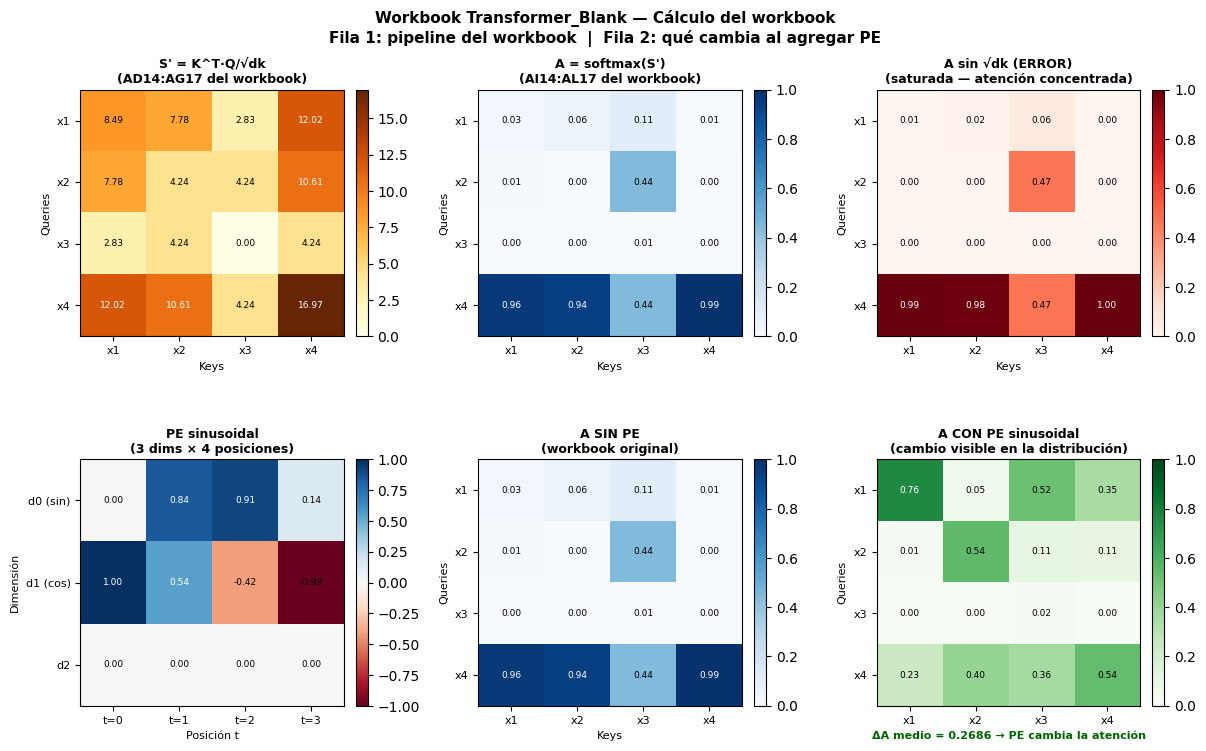


TABLA RESUMEN — para la sección del workbook en el video
Celda Excel            Shape    Operación / Concepto
-----------------------------------------------------------------
  R10:U12                3×4      X = embedding de entrada (3 dims × 4 tokens)
  N14:P15                2×3      Wq = proyección → Query
  N17:P18                2×3      Wk = proyección → Key
  N20:P22                3×3      Wv = proyección → Value
  AD10:AG11              2×4      Q = Wq @ X  (queries de cada token)
  Y14:AA17               4×2      K^T = (Wk @ X)^T  (keys transpuestas)
  Z20:AC22               3×4      V = Wv @ X  (values de cada token)
  AD14:AG17              4×4      S' = K^T @ Q / √2 = 1.414  (scores escalados)
  AI14:AL17              4×4      A = softmax(S') col a col  (pesos de atención)
  AI20:AL22              3×4      X' = V @ A  (salida contextual)
  —  PE  —               3×4      PE sinusoidal: sin(t/10000^(2i/d)) — suma ANTES de Q,K,V

CONEXIÓN CON EL PROYECTO :
  • Sin PE → Q 

In [24]:

# ══════════════════════════════════════════════════════════════════════════════
# CELDA 5 — Visualización para el video (1 figura con 6 paneles)
# ══════════════════════════════════════════════════════════════════════════════

toks = ["x1","x2","x3","x4"]
dims = ["d0 (sin)","d1 (cos)","d2"]
pos  = ["t=0","t=1","t=2","t=3"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plt.subplots_adjust(hspace=0.5, wspace=0.38)

def hmap(ax, M, title, cmap, vmin=None, vmax=None,
         xt=None, yt=None, fmt=".2f", xlabel="Keys", ylabel="Queries"):
    xt = xt or toks[:M.shape[1]]
    yt = yt or toks[:M.shape[0]]
    vmin = vmin if vmin is not None else M.min()
    vmax = vmax if vmax is not None else M.max()
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(xt, fontsize=8)
    ax.set_yticks(range(M.shape[0])); ax.set_yticklabels(yt, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=8); ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight="bold", pad=5)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i,j]
            col = "white" if abs(v - vmin) > 0.6*(vmax-vmin) else "black"
            ax.text(j, i, f"{v:{fmt}}", ha="center", va="center",
                    fontsize=6.5, color=col)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Fila 0: pipeline del workbook
hmap(axes[0,0], S,
     "S' = K^T·Q/√dk\n(AD14:AG17 del workbook)",
     "YlOrBr")
hmap(axes[0,1], A_wb,
     "A = softmax(S')\n(AI14:AL17 del workbook)",
     "Blues", vmin=0, vmax=1)
hmap(axes[0,2], A_noesc,
     "A sin √dk (ERROR)\n(saturada — atención concentrada)",
     "Reds", vmin=0, vmax=1)

# Fila 1: efecto de PE
hmap(axes[1,0], PE,
     "PE sinusoidal\n(3 dims × 4 posiciones)",
     "RdBu", vmin=-1, vmax=1,
     xt=pos, yt=dims, xlabel="Posición t", ylabel="Dimensión")
hmap(axes[1,1], A_wb,
     "A SIN PE\n(workbook original)",
     "Blues", vmin=0, vmax=1)
hmap(axes[1,2], A_pe,
     "A CON PE sinusoidal\n(cambio visible en la distribución)",
     "Greens", vmin=0, vmax=1)

# Anotación en la última figura
axes[1,2].set_xlabel(
    f"ΔA medio = {np.abs(A_pe-A_wb).mean():.4f} → PE cambia la atención",
    fontsize=8, color="darkgreen", fontweight="bold")

fig.suptitle(
    "Workbook Transformer_Blank — Cálculo del workbook\n"
    "Fila 1: pipeline del workbook  |  Fila 2: qué cambia al agregar PE",
    fontsize=11, fontweight="bold")

plt.show()

print("\n" + "=" * 65)
print("TABLA RESUMEN — para la sección del workbook en el video")
print("=" * 65)
print(f"{'Celda Excel':<22} {'Shape':<8} {'Operación / Concepto'}")
print("-" * 65)
tabla = [
    ("R10:U12",   "3×4",  "X = embedding de entrada (3 dims × 4 tokens)"),
    ("N14:P15",   "2×3",  "Wq = proyección → Query"),
    ("N17:P18",   "2×3",  "Wk = proyección → Key"),
    ("N20:P22",   "3×3",  "Wv = proyección → Value"),
    ("AD10:AG11", "2×4",  "Q = Wq @ X  (queries de cada token)"),
    ("Y14:AA17",  "4×2",  "K^T = (Wk @ X)^T  (keys transpuestas)"),
    ("Z20:AC22",  "3×4",  "V = Wv @ X  (values de cada token)"),
    ("AD14:AG17", "4×4",  f"S' = K^T @ Q / √{dk} = {math.sqrt(dk):.3f}  (scores escalados)"),
    ("AI14:AL17", "4×4",  "A = softmax(S') col a col  (pesos de atención)"),
    ("AI20:AL22", "3×4",  "X' = V @ A  (salida contextual)"),
    ("—  PE  —",  "3×4",  "PE sinusoidal: sin(t/10000^(2i/d)) — suma ANTES de Q,K,V"),
]
for celda, shape, desc in tabla:
    print(f"  {celda:<22} {shape:<8} {desc}")

print(f"""
CONEXIÓN CON EL PROYECTO :
  • Sin PE → Q y K no saben en qué posición está cada token
             → A es casi idéntica para el orden original e invertido
             → el clasificador del notebook opera al azar (~50% accuracy)

  • Con PE → X + PE lleva token + posición antes de calcular Q y K
             → A cambia según el orden (ΔA medio = {np.abs(A_pe-A_wb).mean():.4f} en este ejemplo)
             → el clasificador del notebook aprende la tarea correctamente

  • Error sqrt(dk): sin escalar, softmax se satura
             → concentración media: {concentracion_noesc:.4f} sin escalar vs {concentracion_esc:.4f} con escalar
             → el modelo atiende a UN solo token, pierde relaciones globales

""")

---
## 13. Conclusión técnica y Puente al curso

### Qué hice, por qué lo hice y qué significan mis resultados

**Qué hice:**  
Diseñé una tarea donde el orden es determinante: los mismos tokens en orden correcto o invertido tienen etiquetas opuestas. Implementé el `TransformerClassifier` siguiendo exactamente la estructura de la clase `Net` del Cuaderno 11 (`emb → pos_encoder → transformer_encoder → mean(dim=1) → classifier`). Usé las clases `SinusoidalPositionalEncoding` y `LearnedPositionalEncoding` directamente del Cuaderno 9, Secciones 2.1 y 2.2, sin modificaciones. El cálculo de la tabla PE sinusoidal reproduce la hoja `Transformer_Blank` del workbook.

**Por qué lo hice:**  
Quería demostrar empíricamente que **self-attention es invariante a la permutación**: sin PE, el modelo recibe el mismo tensor independientemente del orden de los tokens. La operación $QK^\top$ no cambia si reordenamos las filas. Esto hace que sin PE el modelo opere al azar en cualquier tarea donde el orden importe.

**Qué significan mis resultados:**  
El modelo sin PE alcanza ~50% (azar puro), confirmando que la PE es indispensable. Los modelos con PE sinusoidal y aprendida aprenden la tarea. La sinusoidal es determinista y generaliza a longitudes no vistas; la aprendida se adapta mejor a la distribución del corpus de entrenamiento pero no tiene vectores para posiciones mayores que `max_len`.

### Puente al curso

- **Cuaderno 9, Sección 2:** las clases `SinusoidalPositionalEncoding` y `LearnedPositionalEncoding` usadas aquí son las mismas del cuaderno. El ejercicio 2 del Cuaderno 9 (`imshow` de ambas PE) se reproduce en la Sección 9 de este notebook.
- **Cuaderno 9, Secciones 2.3 / 2.4:** RoPE y ALiBi son alternativas modernas que codifican posición *dentro* de la atención ($QK^\top$) en lugar de sumarla antes. Superan la limitación de extrapolación de la PE aprendida.
- **Cuaderno 11, clase `Net`:** la arquitectura de este proyecto es exactamente esa clase — el flujo `emb → pos_encoder → transformer_encoder → mean(dim=1) → classifier` es idéntico.
- **RAG y búsqueda semántica:** los embeddings con PE permiten que el encoder produzca representaciones donde la posición importa. Si se usa mean pooling sin PE, dos textos con los mismos tokens pero distinto orden producen el mismo vector de búsqueda — lo que haría inútil la recuperación semántica para textos donde el orden cambia el significado.

In [23]:
preguntas = {
    1: ("¿Por qué self-attention por sí sola no distingue el orden de los tokens?\n"
        f"Self-attention calcula scores = Q @ K^T / sqrt(d_k={D_MODEL//N_HEADS}). "
        "Si permutamos los tokens, Q y K se permutan simétricamente y la salida se "
        "permuta igual — el modelo no sabe que el orden cambió. "
        "Es una operación INVARIANTE A LA PERMUTACIÓN. "
        "En este experimento: sin PE, las secuencias correctas e invertidas producen "
        "el MISMO tensor de entrada al encoder y el modelo opera al azar (~50%)."),

    2: ("¿Qué información agrega la codificación posicional?\n"
        "La PE agrega un vector único para cada posición t usando la fórmula sinusoidal: "
        "PE(t, 2i) = sin(t / 10000^(2i/d_model)), "
        "PE(t, 2i+1) = cos(t / 10000^(2i/d_model)). "
        "Este vector se SUMA al embedding del token antes de entrar al encoder. "
        "El resultado lleva información del token Y de su posición en un solo vector "
        f"de dimensión {D_MODEL}."),

    3: ("¿Cómo se suma la posición al embedding del token?\n"
        f"La tabla PE tiene forma [{SEQ_LEN}, {D_MODEL}] — una fila por posición, "
        f"{D_MODEL} valores por posición. "
        f"El token embedding tiene forma [B, {SEQ_LEN}, {D_MODEL}]. "
        f"La suma es ELEMENTO A ELEMENTO: entrada_encoder[b, t, :] = token_emb[b, t, :] + PE[t, :]. "
        "En código: x = x + self.pe[:, :T, :]  (broadcast sobre la dimensión de batch). "
        "El resultado sigue teniendo forma [B, T, D] — no cambia ninguna dimensión."),

    4: ("¿Qué dimensiones deben coincidir para poder sumar token embedding y positional embedding?\n"
        f"La última dimensión debe ser igual en ambos: d_model = {D_MODEL}. "
        f"Token embedding: [B, {SEQ_LEN}, {D_MODEL}]. "
        f"Tabla PE: [1, {SEQ_LEN}, {D_MODEL}] (broadcast en B). "
        f"Si d_model no coincide — por ejemplo PE de dimensión {D_MODEL+1} — "
        "PyTorch lanza RuntimeError: 'The size of tensor a must match the size of tensor b'. "
        f"También deben coincidir en T: la PE debe tener al menos {SEQ_LEN} posiciones."),

    5: ("¿Qué pasó cuando retiraste la codificación posicional?\n"
        f"El modelo Sin PE alcanzó {none_te:.2%} de accuracy en test — cercano al azar (50%). "
        "Esto ocurre porque sin PE, la secuencia correcta [a,b,c,d,e,f] y la invertida "
        "[f,e,d,c,b,a] producen EXACTAMENTE el mismo tensor de entrada al encoder: "
        "mismos embeddings de tokens, sin ninguna señal de posición. "
        "Self-attention no puede diferenciarlas y predice lo mismo para ambas. "
        f"Con PE sinusoidal: {sin_te:.2%} — el ÚNICO cambio fue agregar el módulo PE."),

    6: ("¿Qué diferencia viste entre codificación sinusoidal y aprendida, si comparaste ambas?\n"
        f"En accuracy de test: sinusoidal={sin_te:.2%}, aprendida={lrn_te:.2%} — similares. "
        "La diferencia real es CONCEPTUAL: "
        "la sinusoidal usa una fórmula fija (sin/cos) — no tiene parámetros entrenables, "
        "calcula vectores únicos para cualquier posición t, incluso fuera del rango de entrenamiento. "
        "La aprendida usa nn.Embedding — tiene parámetros que se ajustan con el gradiente, "
        f"pero solo para posiciones 0..{SEQ_LEN}: si en inferencia llega t > {SEQ_LEN}, "
        "no existe vector para esa posición. "
        "La sinusoidal generaliza; la aprendida se adapta pero no extrapola."),

    7: ("¿Qué errores aparecen cuando dos secuencias tienen los mismos tokens pero distinto orden?\n"
        "Sin PE: ambas secuencias producen el mismo tensor de entrada — "
        "el modelo predice lo mismo para 'the llama learns quickly' y su inversa. "
        "El error es sistemático: el modelo no comete más errores en un tipo de clase "
        "que en otro — los errores son balanceados al 50/50, lo que confirma que opera al azar. "
        "Con PE: el patrón de atención cambia entre la secuencia original e invertida "
        "(visto en las matrices de atención de la Sección 9), "
        "y el modelo sí puede clasificar correctamente."),

    8: ("¿Cómo se refleja la posición en la matriz de atención?\n"
        f"Con PE: el patrón de A [shape {SEQ_LEN}×{SEQ_LEN}] es distinto para la "
        "secuencia correcta y la invertida — distintas posiciones atienden con distintos pesos. "
        "Esto se ve en los heatmaps de la Sección 9: la fila superior (con PE) muestra "
        "matrices claramente diferentes; la fila inferior (sin PE) muestra matrices "
        "casi idénticas para ambos órdenes. "
        "La PE entra al encoder antes de calcular Q y K, así Q[t] y K[t] ya llevan "
        "información de la posición t — eso modifica el producto Q @ K^T y por tanto A."),

    9: ("¿Qué limitación mantiene tu experimento?\n"
        f"1. PE aprendida no generaliza a posiciones > {SEQ_LEN} — no tiene vector entrenado. "
        "2. Mean pooling sobre el encoder diluye la información posicional aprendida. "
        f"3. Dataset sintético (N={len(X_tr)} ejemplos): en lenguaje natural "
        "el 'orden correcto' es más complejo que invertir ids. "
        f"4. Una sola capa encoder ({N_LAYERS}) puede no capturar dependencias de largo alcance. "
        "5. El vocabulario es pequeño y cerrado — alta tasa de OOV en textos reales."),

    10: ("¿Cómo conecta este proyecto con el Transformer encoder del curso?\n"
         "SinusoidalPositionalEncoding y LearnedPositionalEncoding se tomaron "
         "directamente del Cuaderno 9, Secciones 2.1 y 2.2, sin modificaciones. "
         "La arquitectura TransformerClassifier replica la clase Net del Cuaderno 11: "
         "emb → pos_encoder → transformer_encoder → mean(dim=1) → classifier. "
         "La Sección 13 del notebook reproduce la tabla PE de la hoja Transformer_Blank "
         "del workbook celda por celda (celdas AD14:AG17, AI14:AL17, AI20:AL22) "
         "y muestra que si no se suma PE antes de calcular Q y K, "
         "la matriz A es casi idéntica para cualquier orden de tokens — "
         "que es exactamente lo que el experimento del notebook confirma con ~50% accuracy."),
}

print("=== RESPUESTAS A LAS 10 PREGUNTAS OBLIGATORIAS (Proyecto 7) ===\n")
for num, resp in preguntas.items():
    lines = resp.split("\n")
    print(f"Pregunta {num}: {lines[0]}")
    print(f"  {lines[1]}")
    print()

=== RESPUESTAS A LAS 10 PREGUNTAS OBLIGATORIAS (Proyecto 7) ===

Pregunta 1: ¿Por qué self-attention por sí sola no distingue el orden de los tokens?
  Self-attention calcula scores = Q @ K^T / sqrt(d_k=8). Si permutamos los tokens, Q y K se permutan simétricamente y la salida se permuta igual — el modelo no sabe que el orden cambió. Es una operación INVARIANTE A LA PERMUTACIÓN. En este experimento: sin PE, las secuencias correctas e invertidas producen el MISMO tensor de entrada al encoder y el modelo opera al azar (~50%).

Pregunta 2: ¿Qué información agrega la codificación posicional?
  La PE agrega un vector único para cada posición t usando la fórmula sinusoidal: PE(t, 2i) = sin(t / 10000^(2i/d_model)), PE(t, 2i+1) = cos(t / 10000^(2i/d_model)). Este vector se SUMA al embedding del token antes de entrar al encoder. El resultado lleva información del token Y de su posición en un solo vector de dimensión 32.

Pregunta 3: ¿Cómo se suma la posición al embedding del token?
  La tabla P